# 02 — Majority baseline

Referencia trivial obligatoria (TDT §8.2). `DummyClassifier(strategy='most_frequent')` predice siempre la clase mayoritaria del train. Su F1-macro es el suelo que cualquier modelo serio debe superar holgadamente.

**Objetivo:** accuracy ≈ proporción de la clase mayoritaria; F1-macro ≈ 0.17–0.23 sobre el split balanceado de tres clases.

## 1. Bootstrap

In [1]:
REPO_URL = 'https://github.com/elvinsomon/pln-poc.git'

import os, sys, subprocess
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir('/content/pln-poc'):
        subprocess.run(['git', 'clone', REPO_URL, '/content/pln-poc'], check=True)
    os.chdir('/content/pln-poc')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.colab import setup_environment, bootstrap_dataset
from src.utils.config import load_config
from src.data.splits import prepare_splits, load_splits
from src.models.majority import train_majority
from src.evaluation.metrics import compute_metrics, save_metrics, plot_confusion

setup_environment(seed=42, project_root=PROJECT_ROOT)
cfg = load_config('data.yaml')
bootstrap_dataset(cfg)
print('cwd:', os.getcwd())

cwd: /Users/elvinsomon/Documents/US/2doCuatrimestre/Procesamiento del Lenguaje Natural (PLN)/Tarea02/PoC-C2


## 2. Preparar splits (idempotente)

Primera ejecución: lee el CSV, filtra `documentation`, aplica `anonymize` + `clean_text`, muestrea 10k/clase, persiste `train/val/test.parquet`. Siguientes ejecuciones: no-op.

In [2]:
prepare_splits(cfg, project_root=PROJECT_ROOT)
splits = load_splits(cfg, project_root=PROJECT_ROOT)
for name, df in splits.items():
    print(f'{name:5s} n={len(df):>6,}  dist={df["label"].value_counts().to_dict()}')

train n=24,000  dist={'question': 8000, 'feature': 8000, 'bug': 8000}
val   n= 3,000  dist={'bug': 1000, 'feature': 1000, 'question': 1000}
test  n= 3,000  dist={'question': 1000, 'feature': 1000, 'bug': 1000}


## 3. Entrenar + evaluar

In [3]:
labels = cfg['classes']
X_train, y_train = splits['train']['text'], splits['train']['label']
X_test,  y_test  = splits['test']['text'],  splits['test']['label']

clf = train_majority(X_train, y_train, seed=cfg['seed'])
y_pred = clf.predict(X_test)

metrics = compute_metrics(y_test, y_pred, labels=labels)
print(metrics['report'])
print('accuracy :', round(metrics['accuracy'], 4))
print('f1_macro :', round(metrics['f1_macro'], 4))

              precision    recall  f1-score   support

         bug     0.3333    1.0000    0.5000      1000
     feature     0.0000    0.0000    0.0000      1000
    question     0.0000    0.0000    0.0000      1000

    accuracy                         0.3333      3000
   macro avg     0.1111    0.3333    0.1667      3000
weighted avg     0.1111    0.3333    0.1667      3000

accuracy : 0.3333
f1_macro : 0.1667


## 4. Matriz de confusión y persistencia

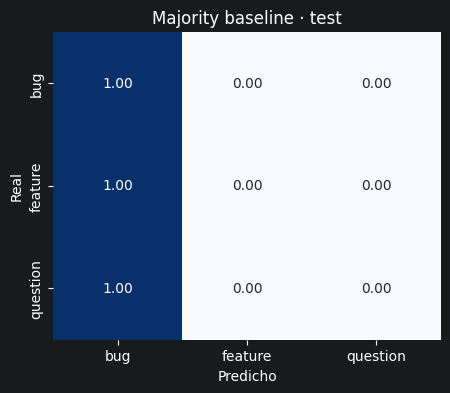

saved metrics ✔


In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(metrics['confusion_matrix']['matrix'], labels=labels, ax=ax, normalize=True)
ax.set_title('Majority baseline · test')
plt.show()

save_metrics(metrics, f"{cfg['paths']['metrics']}/majority.json")
print('saved metrics ✔')

## 5. Lectura del resultado

- Matriz de confusión con toda la masa en una columna (clase mayoritaria): el modelo nunca predice otra.
- `accuracy ≈ 1/3` y `f1_macro ≈ 0.17–0.23`: suelo que TF-IDF+SVM (notebook 03) debe superar con claridad.